 Model loaded
 Data loaded: (20319, 23, 7)
 SHAP explainer ready


C:\Users\NZALI SYLLA\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_deep\deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


 SHAP values computed


C:\Users\NZALI SYLLA\AppData\Local\Temp\ipykernel_26224\3863763298.py:112: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_flat)


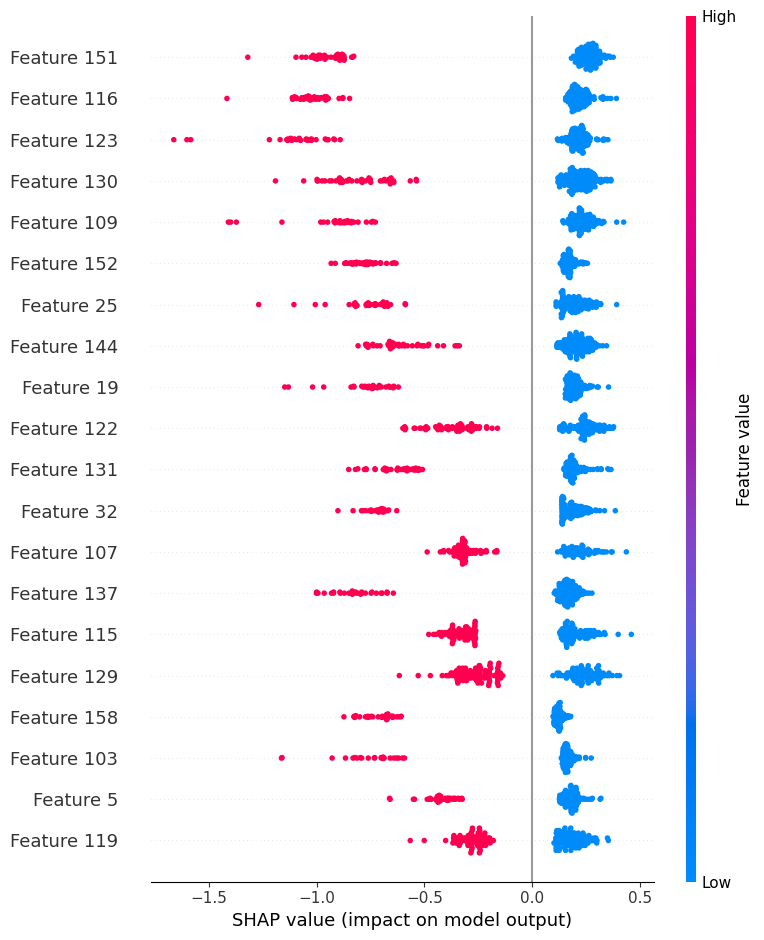


 INTERPRETATION:
 SHAP montre quelles parties de la séquence influencent les prédictions.
 Certaines positions sont beaucoup plus importantes que d'autres.
 Le modèle utilise des régions spécifiques pour prédire les off-targets.


In [11]:
# ============================================================
# 1. FIX PATH (same as before)
# ============================================================

import sys
import os

sys.path.insert(0, "../app/ml")
# ============================================================
# 2. IMPORTS
# ============================================================

from dl_model import load_model, build_dataset_mismatch

import shap
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn


# ============================================================
# 3. LOAD MODEL
# ============================================================

model_path = "../models/K562_mismatch.pt"
model = load_model(model_path)

model.eval()  # mode inference

print(" Model loaded")


# ============================================================
# 4. LOAD DATASET
# ============================================================

data_path = "../data/K562.csv"

X, y, groups = build_dataset_mismatch(data_path)

print(" Data loaded:", X.shape)


# ============================================================
# 5. TAKE SMALL SAMPLE (IMPORTANT)
# ============================================================

# SHAP est coûteux → petit subset
X_sample = X[:200]

# tensor avec gradients
X_tensor = torch.from_numpy(X_sample).float()
X_tensor.requires_grad_()  #  indispensable


# ============================================================
# 6. WRAPPER MODEL (fix pour SHAP)
# ============================================================

class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        logits, _ = self.model(x)      # ignore attention
        return logits.unsqueeze(1)     #  shape (B,1) obligatoire


wrapped_model = ModelWrapper(model)


# ============================================================
# 7. SHAP EXPLAINER
# ============================================================

explainer = shap.DeepExplainer(wrapped_model, X_tensor)

print(" SHAP explainer ready")


# ============================================================
# 8. COMPUTE SHAP VALUES (FIX CRITIQUE)
# ============================================================

shap_values = explainer.shap_values(
    X_tensor,
    check_additivity=False   #  FIX IMPORTANT pour DL
)

print(" SHAP values computed")


# ============================================================
# 9. PREPARE DATA FOR VISUALIZATION
# ============================================================

# SHAP peut retourner une liste
shap_vals = shap_values[0] if isinstance(shap_values, list) else shap_values

# flatten (L, 7 → vecteur)
shap_vals = shap_vals.reshape(shap_vals.shape[0], -1)
X_flat = X_sample.reshape(X_sample.shape[0], -1)


# ============================================================
# 10. VISUALIZATION
# ============================================================

shap.summary_plot(shap_vals, X_flat)


# ============================================================
# 11. INTERPRETATION
# ============================================================

print("\n INTERPRETATION:")
print(" SHAP montre quelles parties de la séquence influencent les prédictions.")
print(" Certaines positions sont beaucoup plus importantes que d'autres.")
print(" Le modèle utilise des régions spécifiques pour prédire les off-targets.")

In [12]:
# ============================================================
# 12. AGGREGATE SHAP BY POSITION
# ============================================================

# original shape: (samples, sequence_length, 7 features)
shap_vals_raw = shap_values[0] if isinstance(shap_values, list) else shap_values

# take absolute values (importance)
shap_vals_abs = np.abs(shap_vals_raw)

# sum over feature dimension (axis=2 → the 7 channels)
# result → (samples, sequence_length)
shap_per_position = shap_vals_abs.sum(axis=2)

print(" SHAP per position shape:", shap_per_position.shape)

 SHAP per position shape: (200, 23, 1)


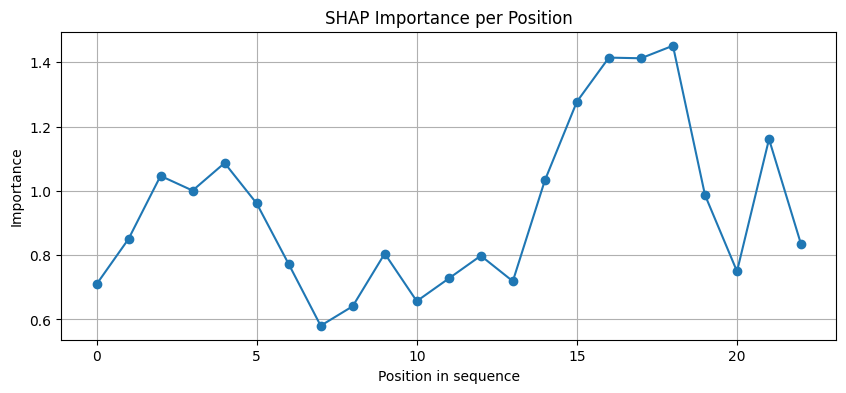

In [13]:
# ============================================================
# 14. PLOT SHAP IMPORTANCE PER POSITION
# ============================================================

import matplotlib.pyplot as plt

# Calculate mean importance per position
mean_importance = shap_per_position.mean(axis=0)

plt.figure(figsize=(10, 4))

plt.plot(mean_importance, marker='o')

plt.title("SHAP Importance per Position")
plt.xlabel("Position in sequence")
plt.ylabel("Importance")

plt.grid()
plt.show()

In [15]:
# ============================================================
# 15. COMPUTE MEAN ATTENTION (SAME SAMPLES AS SHAP)
# ============================================================

# X_tensor already contains the same 200 encoded examples used by SHAP.
device = next(model.parameters()).device

with torch.no_grad():
    _, attention = model(X_tensor.to(device))

attention_array = attention.cpu().numpy()
mean_attention = attention_array.mean(axis=0)

print("Mean attention computed:", mean_attention.shape)


Mean attention computed: (23,)


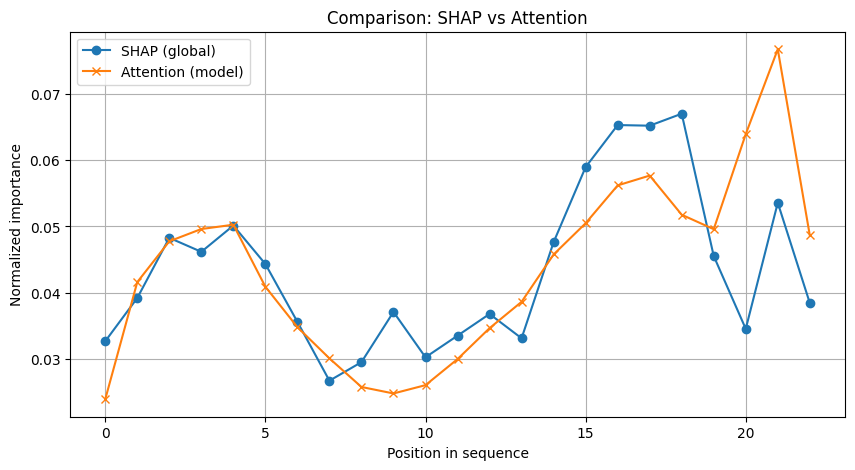

In [16]:
# ============================================================
# 16. COMPARISON PLOT (SHAP vs ATTENTION)
# ============================================================

# Normalize both curves so the plot compares position rankings, not scale.
mean_importance_norm = mean_importance / mean_importance.sum()
mean_attention_norm = mean_attention / mean_attention.sum()

plt.figure(figsize=(10, 5))

plt.plot(mean_importance_norm, label="SHAP (global)", marker="o")
plt.plot(mean_attention_norm, label="Attention (model)", marker="x")

plt.title("Comparison: SHAP vs Attention")
plt.xlabel("Position in sequence")
plt.ylabel("Normalized importance")

plt.legend()
plt.grid()

plt.show()


Hek293t data loaded: (132914, 23, 7)


C:\Users\NZALI SYLLA\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_deep\deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")
C:\Users\NZALI SYLLA\AppData\Local\Temp\ipykernel_26224\1479101698.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_flat_hek, X_flat_hek)


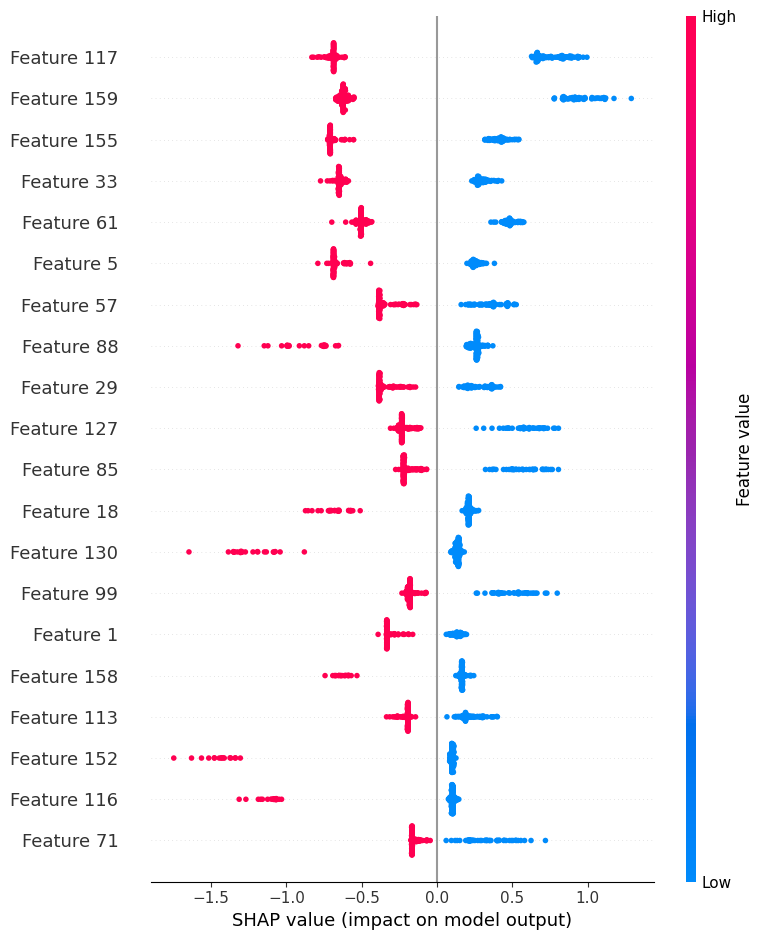

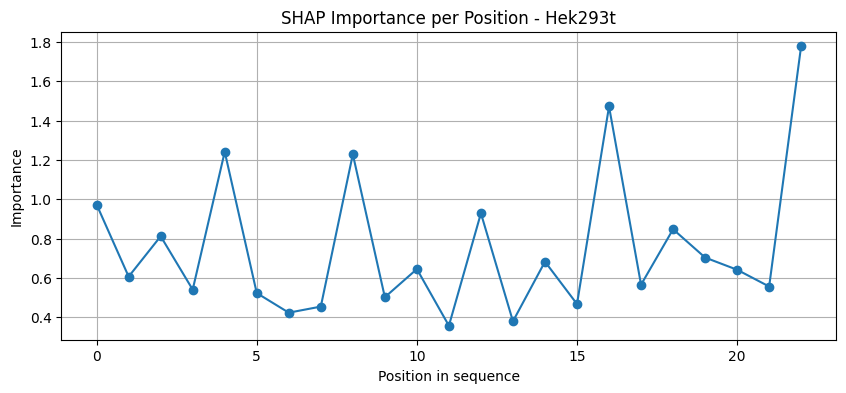

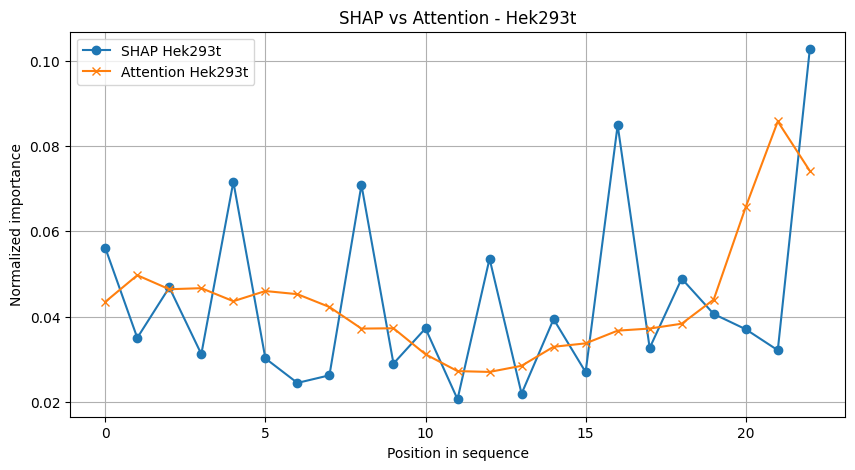

In [21]:
# ============================================================
# 17. SAME ANALYSIS FOR Hek293t DATASET
# ============================================================

from dl_model import build_dataset_mismatch

model_path = "../models/Hek293t_mismatch.pt"
data_path = "../data/Hek293t.csv"

model_hek = load_model(model_path)
model_hek.eval()

X_hek, y_hek, groups_hek = build_dataset_mismatch(data_path)
print("Hek293t data loaded:", X_hek.shape)

X_sample_hek = X_hek[:200]
X_tensor_hek = torch.from_numpy(X_sample_hek).float()
X_tensor_hek.requires_grad_()

wrapped_model_hek = ModelWrapper(model_hek)
explainer_hek = shap.DeepExplainer(wrapped_model_hek, X_tensor_hek)

shap_values_hek = explainer_hek.shap_values(
    X_tensor_hek,
    check_additivity=False
)

shap_vals_hek = shap_values_hek[0] if isinstance(shap_values_hek, list) else shap_values_hek
shap_per_position_hek = np.abs(shap_vals_hek).sum(axis=2)
mean_importance_hek = shap_per_position_hek.mean(axis=0)

# SHAP summary plot
shap_vals_flat_hek = shap_vals_hek.reshape(shap_vals_hek.shape[0], -1)
X_flat_hek = X_sample_hek.reshape(X_sample_hek.shape[0], -1)
shap.summary_plot(shap_vals_flat_hek, X_flat_hek)

# SHAP importance per position
plt.figure(figsize=(10, 4))
plt.plot(mean_importance_hek, marker="o")
plt.title("SHAP Importance per Position - Hek293t")
plt.xlabel("Position in sequence")
plt.ylabel("Importance")
plt.grid()
plt.show()

with torch.no_grad():
    _, attention_hek = model_hek(X_tensor_hek.to(next(model_hek.parameters()).device))

attention_array_hek = attention_hek.cpu().numpy()
mean_attention_hek = attention_array_hek.mean(axis=0)

mean_importance_hek_norm = mean_importance_hek / mean_importance_hek.sum()
mean_attention_hek_norm = mean_attention_hek / mean_attention_hek.sum()

plt.figure(figsize=(10, 5))
plt.plot(mean_importance_hek_norm, label="SHAP Hek293t", marker="o")
plt.plot(mean_attention_hek_norm, label="Attention Hek293t", marker="x")
plt.title("SHAP vs Attention - Hek293t")
plt.xlabel("Position in sequence")
plt.ylabel("Normalized importance")
plt.legend()
plt.grid()
plt.show()


K562Hek293 data loaded: (153233, 23, 7)


C:\Users\NZALI SYLLA\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_deep\deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")
C:\Users\NZALI SYLLA\AppData\Local\Temp\ipykernel_26224\857500063.py:33: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_flat_k562hek, X_flat_k562hek)


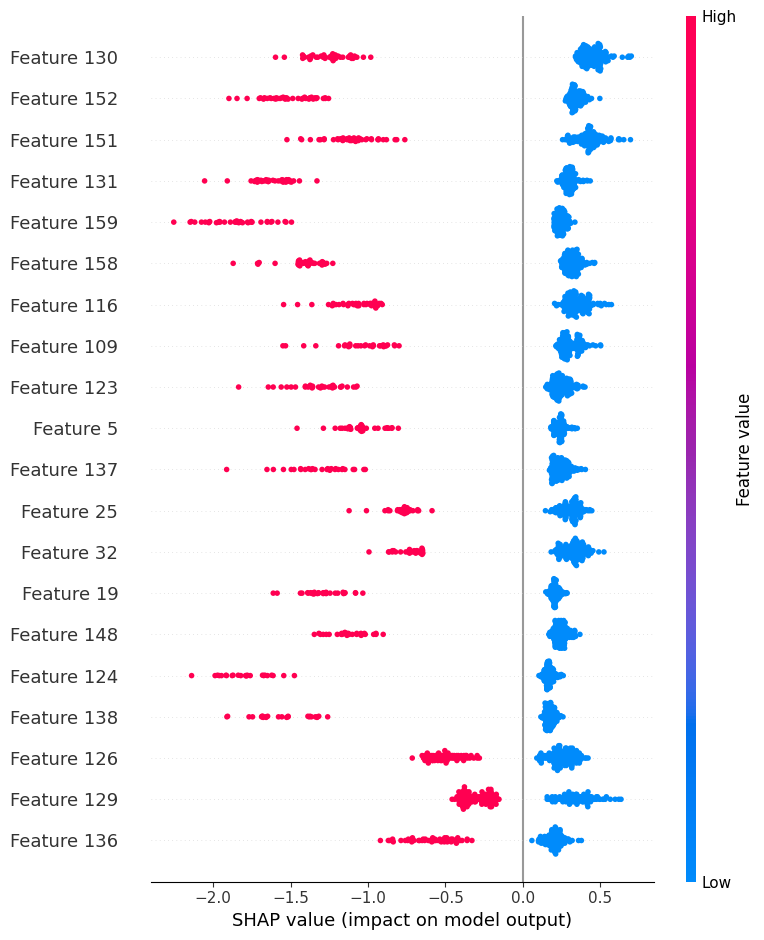

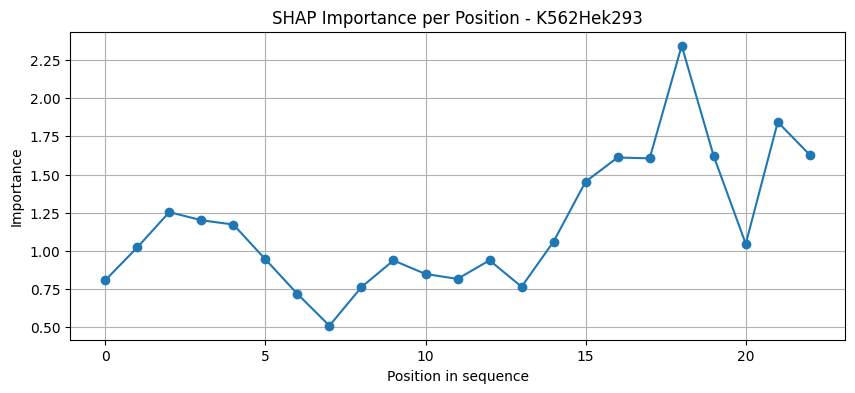

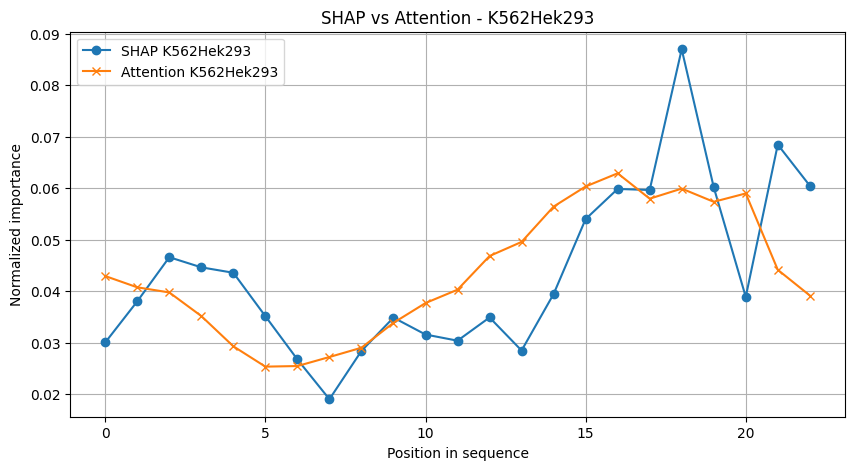

In [22]:
# ============================================================
# 18. SAME ANALYSIS FOR K562Hek293 DATASET
# ============================================================

model_path = "../models/K562Hek293_mismatch.pt"
data_path = "../data/K562Hek293.csv"

model_k562hek = load_model(model_path)
model_k562hek.eval()

X_k562hek, y_k562hek, groups_k562hek = build_dataset_mismatch(data_path)
print("K562Hek293 data loaded:", X_k562hek.shape)

X_sample_k562hek = X_k562hek[:200]
X_tensor_k562hek = torch.from_numpy(X_sample_k562hek).float()
X_tensor_k562hek.requires_grad_()

wrapped_model_k562hek = ModelWrapper(model_k562hek)
explainer_k562hek = shap.DeepExplainer(wrapped_model_k562hek, X_tensor_k562hek)

shap_values_k562hek = explainer_k562hek.shap_values(
    X_tensor_k562hek,
    check_additivity=False
)

shap_vals_k562hek = shap_values_k562hek[0] if isinstance(shap_values_k562hek, list) else shap_values_k562hek
shap_per_position_k562hek = np.abs(shap_vals_k562hek).sum(axis=2)
mean_importance_k562hek = shap_per_position_k562hek.mean(axis=0)

# SHAP summary plot
shap_vals_flat_k562hek = shap_vals_k562hek.reshape(shap_vals_k562hek.shape[0], -1)
X_flat_k562hek = X_sample_k562hek.reshape(X_sample_k562hek.shape[0], -1)
shap.summary_plot(shap_vals_flat_k562hek, X_flat_k562hek)

# SHAP importance per position
plt.figure(figsize=(10, 4))
plt.plot(mean_importance_k562hek, marker="o")
plt.title("SHAP Importance per Position - K562Hek293")
plt.xlabel("Position in sequence")
plt.ylabel("Importance")
plt.grid()
plt.show()

with torch.no_grad():
    _, attention_k562hek = model_k562hek(X_tensor_k562hek.to(next(model_k562hek.parameters()).device))

attention_array_k562hek = attention_k562hek.cpu().numpy()
mean_attention_k562hek = attention_array_k562hek.mean(axis=0)

mean_importance_k562hek_norm = mean_importance_k562hek / mean_importance_k562hek.sum()
mean_attention_k562hek_norm = mean_attention_k562hek / mean_attention_k562hek.sum()

plt.figure(figsize=(10, 5))
plt.plot(mean_importance_k562hek_norm, label="SHAP K562Hek293", marker="o")
plt.plot(mean_attention_k562hek_norm, label="Attention K562Hek293", marker="x")
plt.title("SHAP vs Attention - K562Hek293")
plt.xlabel("Position in sequence")
plt.ylabel("Normalized importance")
plt.legend()
plt.grid()
plt.show()


CIRCLE_seq data loaded: (584949, 24, 7)


C:\Users\NZALI SYLLA\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_deep\deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")
C:\Users\NZALI SYLLA\AppData\Local\Temp\ipykernel_26224\1800807587.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_flat_circle, X_flat_circle)


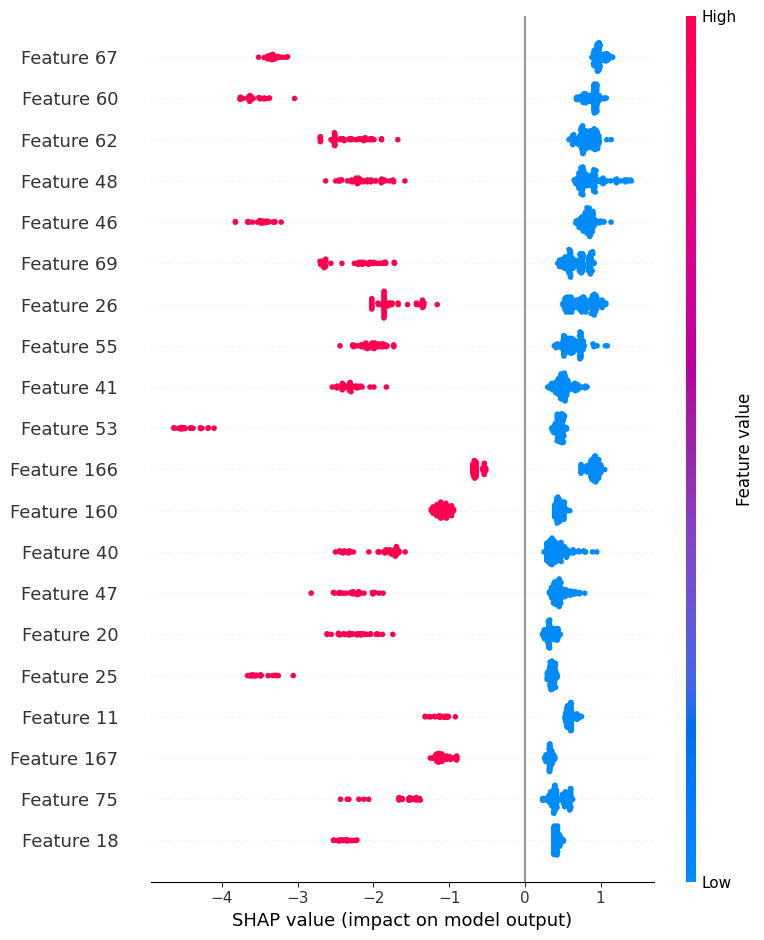

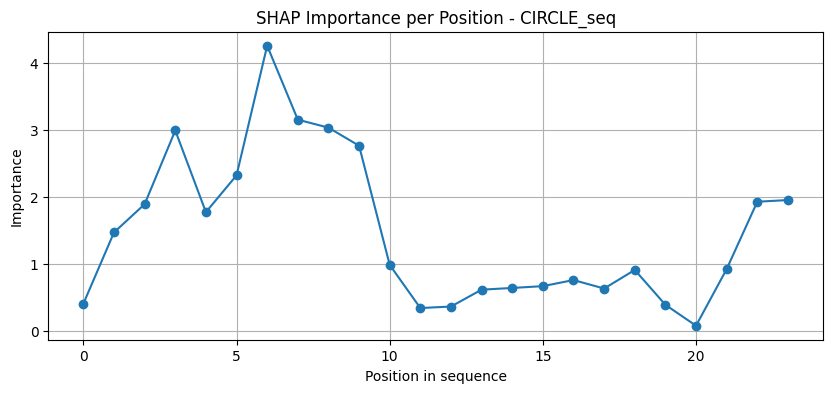

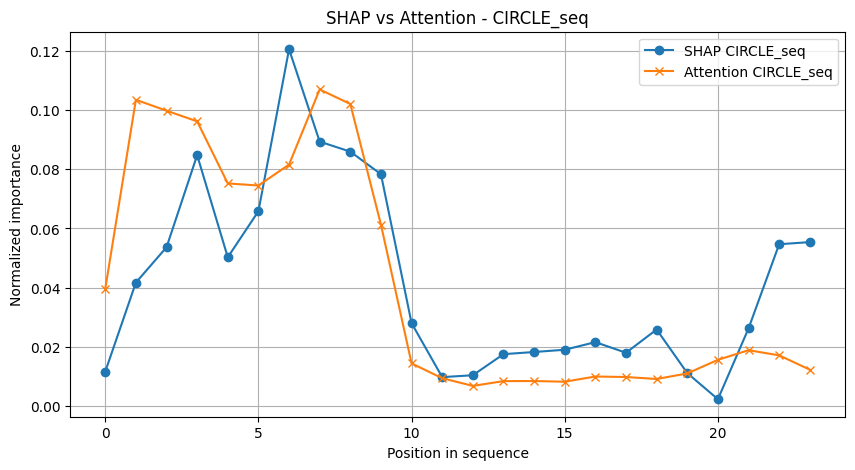

In [23]:
# ============================================================
# 19. SAME ANALYSIS FOR CIRCLE_seq DATASET
# ============================================================

from dl_model import build_dataset_indel

model_path = "../models/CIRCLE_seq_indel.pt"
data_path = "../data/CIRCLE_seq.csv"

model_circle = load_model(model_path)
model_circle.eval()

X_circle, y_circle, groups_circle = build_dataset_indel(data_path)
print("CIRCLE_seq data loaded:", X_circle.shape)

X_sample_circle = X_circle[:200]
X_tensor_circle = torch.from_numpy(X_sample_circle).float()
X_tensor_circle.requires_grad_()

wrapped_model_circle = ModelWrapper(model_circle)
explainer_circle = shap.DeepExplainer(wrapped_model_circle, X_tensor_circle)

shap_values_circle = explainer_circle.shap_values(
    X_tensor_circle,
    check_additivity=False
)

shap_vals_circle = shap_values_circle[0] if isinstance(shap_values_circle, list) else shap_values_circle
shap_per_position_circle = np.abs(shap_vals_circle).sum(axis=2)
mean_importance_circle = shap_per_position_circle.mean(axis=0)

# SHAP summary plot
shap_vals_flat_circle = shap_vals_circle.reshape(shap_vals_circle.shape[0], -1)
X_flat_circle = X_sample_circle.reshape(X_sample_circle.shape[0], -1)
shap.summary_plot(shap_vals_flat_circle, X_flat_circle)

# SHAP importance per position
plt.figure(figsize=(10, 4))
plt.plot(mean_importance_circle, marker="o")
plt.title("SHAP Importance per Position - CIRCLE_seq")
plt.xlabel("Position in sequence")
plt.ylabel("Importance")
plt.grid()
plt.show()

with torch.no_grad():
    _, attention_circle = model_circle(X_tensor_circle.to(next(model_circle.parameters()).device))

attention_array_circle = attention_circle.cpu().numpy()
mean_attention_circle = attention_array_circle.mean(axis=0)

mean_importance_circle_norm = mean_importance_circle / mean_importance_circle.sum()
mean_attention_circle_norm = mean_attention_circle / mean_attention_circle.sum()

plt.figure(figsize=(10, 5))
plt.plot(mean_importance_circle_norm, label="SHAP CIRCLE_seq", marker="o")
plt.plot(mean_attention_circle_norm, label="Attention CIRCLE_seq", marker="x")
plt.title("SHAP vs Attention - CIRCLE_seq")
plt.xlabel("Position in sequence")
plt.ylabel("Normalized importance")
plt.legend()
plt.grid()
plt.show()


GUIDE-Seq data loaded: (213933, 24, 7)


C:\Users\NZALI SYLLA\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_deep\deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")
C:\Users\NZALI SYLLA\AppData\Local\Temp\ipykernel_26224\3464081173.py:33: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_flat_guide, X_flat_guide)


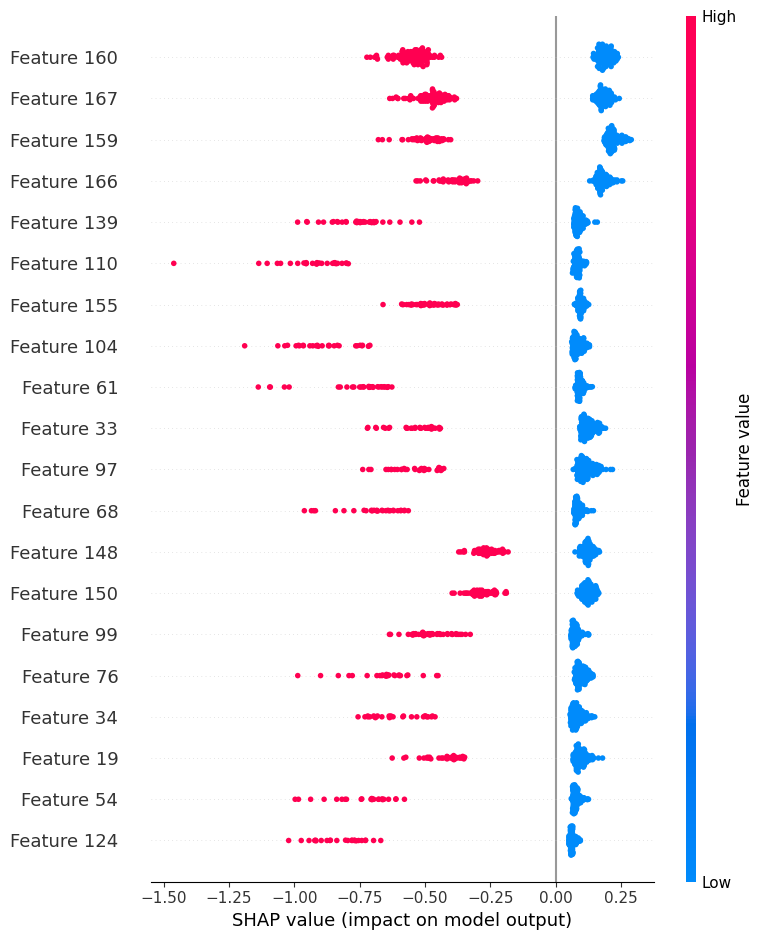

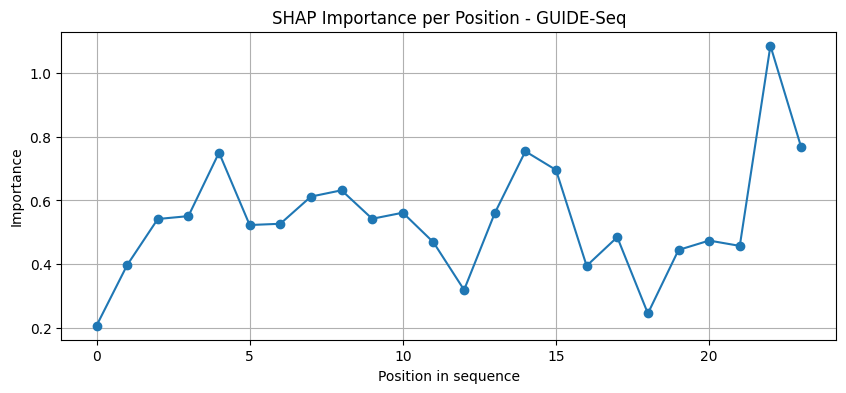

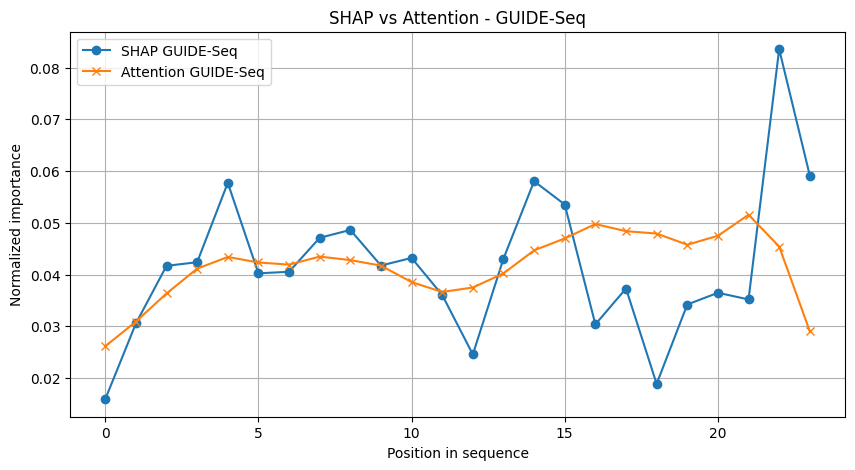

In [24]:
# ============================================================
# 20. SAME ANALYSIS FOR GUIDE-Seq DATASET
# ============================================================

model_path = "../models/GUIDE-Seq_indel.pt"
data_path = "../data/GUIDE-Seq.csv"

model_guide = load_model(model_path)
model_guide.eval()

X_guide, y_guide, groups_guide = build_dataset_indel(data_path)
print("GUIDE-Seq data loaded:", X_guide.shape)

X_sample_guide = X_guide[:200]
X_tensor_guide = torch.from_numpy(X_sample_guide).float()
X_tensor_guide.requires_grad_()

wrapped_model_guide = ModelWrapper(model_guide)
explainer_guide = shap.DeepExplainer(wrapped_model_guide, X_tensor_guide)

shap_values_guide = explainer_guide.shap_values(
    X_tensor_guide,
    check_additivity=False
)

shap_vals_guide = shap_values_guide[0] if isinstance(shap_values_guide, list) else shap_values_guide
shap_per_position_guide = np.abs(shap_vals_guide).sum(axis=2)
mean_importance_guide = shap_per_position_guide.mean(axis=0)

# SHAP summary plot
shap_vals_flat_guide = shap_vals_guide.reshape(shap_vals_guide.shape[0], -1)
X_flat_guide = X_sample_guide.reshape(X_sample_guide.shape[0], -1)
shap.summary_plot(shap_vals_flat_guide, X_flat_guide)

# SHAP importance per position
plt.figure(figsize=(10, 4))
plt.plot(mean_importance_guide, marker="o")
plt.title("SHAP Importance per Position - GUIDE-Seq")
plt.xlabel("Position in sequence")
plt.ylabel("Importance")
plt.grid()
plt.show()

with torch.no_grad():
    _, attention_guide = model_guide(X_tensor_guide.to(next(model_guide.parameters()).device))

attention_array_guide = attention_guide.cpu().numpy()
mean_attention_guide = attention_array_guide.mean(axis=0)

mean_importance_guide_norm = mean_importance_guide / mean_importance_guide.sum()
mean_attention_guide_norm = mean_attention_guide / mean_attention_guide.sum()

plt.figure(figsize=(10, 5))
plt.plot(mean_importance_guide_norm, label="SHAP GUIDE-Seq", marker="o")
plt.plot(mean_attention_guide_norm, label="Attention GUIDE-Seq", marker="x")
plt.title("SHAP vs Attention - GUIDE-Seq")
plt.xlabel("Position in sequence")
plt.ylabel("Normalized importance")
plt.legend()
plt.grid()
plt.show()


In [26]:
# ============================================================
# 22. VERIFY IF THE MODELS WORK WELL
# ============================================================

from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader, TensorDataset

# Set this to a number like 5000 if the full datasets are too slow.
# Keep None to evaluate the full dataset.
EVAL_SAMPLE_SIZE = None

models_to_check = [
    {
        "name": "K562",
        "mode": "mismatch",
        "data_path": "../data/K562.csv",
        "model_path": "../models/K562_mismatch.pt",
        "loader": build_dataset_mismatch,
    },
    {
        "name": "Hek293t",
        "mode": "mismatch",
        "data_path": "../data/Hek293t.csv",
        "model_path": "../models/Hek293t_mismatch.pt",
        "loader": build_dataset_mismatch,
    },
    {
        "name": "K562Hek293",
        "mode": "mismatch",
        "data_path": "../data/K562Hek293.csv",
        "model_path": "../models/K562Hek293_mismatch.pt",
        "loader": build_dataset_mismatch,
    },
    {
        "name": "CIRCLE_seq",
        "mode": "indel",
        "data_path": "../data/CIRCLE_seq.csv",
        "model_path": "../models/CIRCLE_seq_indel.pt",
        "loader": build_dataset_indel,
    },
    {
        "name": "GUIDE-Seq",
        "mode": "indel",
        "data_path": "../data/GUIDE-Seq.csv",
        "model_path": "../models/GUIDE-Seq_indel.pt",
        "loader": build_dataset_indel,
    },
]


def evaluate_saved_model(config, batch_size=512):
    print()
    print("Evaluating:", config["name"])

    model_eval = load_model(config["model_path"])
    model_eval.eval()

    X_eval, y_eval, groups_eval = config["loader"](config["data_path"])

    if EVAL_SAMPLE_SIZE is not None:
        X_eval = X_eval[:EVAL_SAMPLE_SIZE]
        y_eval = y_eval[:EVAL_SAMPLE_SIZE]

    dataset = TensorDataset(
        torch.from_numpy(X_eval).float(),
        torch.from_numpy(y_eval).float()
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    probs = []
    device = next(model_eval.parameters()).device

    with torch.no_grad():
        for xb, yb in loader:
            logits, _ = model_eval(xb.to(device))
            batch_probs = torch.sigmoid(logits).cpu().numpy()
            probs.append(batch_probs)

    probs = np.concatenate(probs)
    preds = (probs >= 0.5).astype(int)
    y_true = y_eval.astype(int)

    results = {
        "dataset": config["name"],
        "mode": config["mode"],
        "n_samples": len(y_true),
        "positives": int(y_true.sum()),
        "positive_rate": float(y_true.mean()),
        "auprc": average_precision_score(y_true, probs),
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }

    try:
        results["auroc"] = roc_auc_score(y_true, probs)
    except ValueError:
        results["auroc"] = np.nan

    print("Samples:", results["n_samples"])
    print("Positives:", results["positives"])
    print("AUPRC:", round(results["auprc"], 4))
    print("AUROC:", round(results["auroc"], 4))
    print("Precision:", round(results["precision"], 4))
    print("Recall:", round(results["recall"], 4))
    print("F1:", round(results["f1"], 4))

    return results


model_check_results = []

for config in models_to_check:
    result = evaluate_saved_model(config)
    model_check_results.append(result)

model_check_df = pd.DataFrame(model_check_results)
model_check_df = model_check_df.sort_values("auprc", ascending=False)
model_check_df



Evaluating: K562
Samples: 20319
Positives: 120
AUPRC: 0.9289
AUROC: 0.9996
Precision: 0.3419
Recall: 1.0
F1: 0.5096

Evaluating: Hek293t
Samples: 132914
Positives: 536
AUPRC: 0.6741
AUROC: 0.9981
Precision: 0.1645
Recall: 1.0
F1: 0.2825

Evaluating: K562Hek293
Samples: 153233
Positives: 656
AUPRC: 0.6664
AUROC: 0.9973
Precision: 0.2179
Recall: 0.9665
F1: 0.3557

Evaluating: CIRCLE_seq
Samples: 584949
Positives: 7371
AUPRC: 0.7368
AUROC: 0.9931
Precision: 0.2034
Recall: 0.9771
F1: 0.3367

Evaluating: GUIDE-Seq
Samples: 213933
Positives: 50
AUPRC: 0.2991
AUROC: 0.9989
Precision: 0.013
Recall: 1.0
F1: 0.0256


,dataset,mode,n_samples,positives,positive_rate,auprc,accuracy,precision,recall,f1,auroc
0,K562,mismatch,20319,120,0.005906,0.928941,0.988631,0.341880,1.000000,0.509554,0.999602
3,CIRCLE_seq,indel,584949,7371,0.012601,0.736803,0.951485,0.203377,0.977072,0.336676,0.993115
1,Hek293t,mismatch,132914,536,0.004033,0.674073,0.979513,0.164468,1.000000,0.282477,0.998119
2,K562Hek293,mismatch,153233,656,0.004281,0.666442,0.985010,0.217944,0.966463,0.355680,0.997302
4,GUIDE-Seq,indel,213933,50,0.000234,0.299056,0.982186,0.012950,1.000000,0.025569,0.998855
